In [3]:
import pandas as pd
import requests
from getpass import getpass

# Enter your Census API key securely.
# It will NOT appear in the notebook output.
CENSUS_API_KEY = getpass("Enter your Census API key: ")


Enter your Census API key:  ········


In [5]:
# Census API endpoint: 2015 ACS 5-Year Data Profiles
BASE_URL = "https://api.census.gov/data/2015/acs/acs5/profile"

# Variables for the QSS 45 analysis
variables = {
    "NAME": "NAME",
    "MeanCommute": "DP03_0025E",
    "Transit": "DP03_0021PE",
    "Income": "DP03_0062E",
    "Poverty": "DP03_0128PE",
    "Unemployment": "DP03_0009PE",
    "WorkAtHome": "DP03_0024PE"
}

# New York state and county codes
STATE = "36"
BRONX_COUNTY = "005"
MANHATTAN_COUNTY = "061"



In [7]:
def fetch_county_tracts(county_code, borough_name):
    params = {
        "get": ",".join(variables.values()),
        "for": "tract:*",
        "in": f"state:{STATE} county:{county_code}",
        "key": CENSUS_API_KEY
    }

    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()

    rows = response.json()

    df = pd.DataFrame(
        rows[1:],
        columns=rows[0]
    )

    # Rename Census variable codes to readable names
    rename_map = {code: name for name, code in variables.items()}
    df = df.rename(columns=rename_map)

    # Add borough name and a full tract GEOID
    df["Borough"] = borough_name
    df["GEOID"] = df["state"] + df["county"] + df["tract"]

    return df


bronx = fetch_county_tracts(
    BRONX_COUNTY,
    "Bronx"
)

manhattan = fetch_county_tracts(
    MANHATTAN_COUNTY,
    "Manhattan"
)

print("Bronx tracts:", len(bronx))
print("Manhattan tracts:", len(manhattan))

Bronx tracts: 339
Manhattan tracts: 288


In [9]:
# Combine Bronx and Manhattan into one dataframe
df = pd.concat([bronx, manhattan], ignore_index=True)

print("Combined shape:", df.shape)
print()
print(df.head())
print()
print(df.columns.tolist())

Combined shape: (627, 12)

                                       NAME MeanCommute Transit Income  \
0  Census Tract 351, Bronx County, New York        45.2    43.2  71913   
1  Census Tract 367, Bronx County, New York        40.3    61.2  23720   
2  Census Tract 381, Bronx County, New York        45.4    65.0  25891   
3  Census Tract 388, Bronx County, New York        42.6    45.3  51298   
4  Census Tract 397, Bronx County, New York        29.1    36.3  21228   

  Poverty Unemployment WorkAtHome state county   tract Borough        GEOID  
0    17.1         14.1        7.5    36    005  035100   Bronx  36005035100  
1    49.8         15.4        2.4    36    005  036700   Bronx  36005036700  
2    34.3         19.5        7.2    36    005  038100   Bronx  36005038100  
3    20.5         24.5        1.5    36    005  038800   Bronx  36005038800  
4    51.0          9.2       10.1    36    005  039700   Bronx  36005039700  

['NAME', 'MeanCommute', 'Transit', 'Income', 'Poverty', 'Un

In [11]:
# Variables that should be numeric
numeric_cols = [
    "MeanCommute",
    "Transit",
    "Income",
    "Poverty",
    "Unemployment",
    "WorkAtHome"
]

# Convert Census API strings to numbers
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Rows before cleaning:", len(df))
print()

print("Missing values:")
print(df[numeric_cols].isna().sum())

print("\nNegative values:")
print((df[numeric_cols] < 0).sum())

print("\nMaximum values:")
print(df[numeric_cols].max())

Rows before cleaning: 627

Missing values:
MeanCommute     0
Transit         0
Income          0
Poverty         0
Unemployment    0
WorkAtHome      0
dtype: int64

Negative values:
MeanCommute     18
Transit         11
Income          21
Poverty         10
Unemployment    10
WorkAtHome      11
dtype: int64

Maximum values:
MeanCommute         58.5
Transit            100.0
Income          250001.0
Poverty            100.0
Unemployment       100.0
WorkAtHome         100.0
dtype: float64


In [13]:
# Make a clean copy
clean = df.copy()

print("Rows before cleaning:", len(clean))

# Replace negative Census special values with missing
for col in numeric_cols:
    clean.loc[clean[col] < 0, col] = pd.NA

# Remove the ACS special income value
clean.loc[clean["Income"] == 250001, "Income"] = pd.NA

# Drop rows missing any analysis variable
clean = clean.dropna(subset=numeric_cols).copy()

print("Rows after cleaning:", len(clean))
print()
print(clean["Borough"].value_counts())

Rows before cleaning: 627
Rows after cleaning: 602

Borough
Bronx        327
Manhattan    275
Name: count, dtype: int64


In [15]:
# Save the cleaned QSS 45 analysis dataset
clean.to_csv("qss45_bronx_manhattan_clean.csv", index=False)

print("Saved:", clean.shape)


Saved: (602, 12)


In [17]:
summary = clean.groupby("Borough").agg(
    n=("MeanCommute", "size"),
    mean_commute=("MeanCommute", "mean"),
    median_commute=("MeanCommute", "median"),
    mean_transit=("Transit", "mean"),
    median_income=("Income", "median"),
    mean_poverty=("Poverty", "mean"),
    mean_unemployment=("Unemployment", "mean"),
    mean_work_at_home=("WorkAtHome", "mean")
).round(2)

summary

,n,mean_commute,median_commute,mean_transit,median_income,mean_poverty,mean_unemployment,mean_work_at_home
Borough,,,,,,,,
Bronx,327,42.63,42.6,59.05,33095.0,29.59,13.91,3.27
Manhattan,275,30.80,30.3,58.14,81250.0,17.56,7.64,6.85


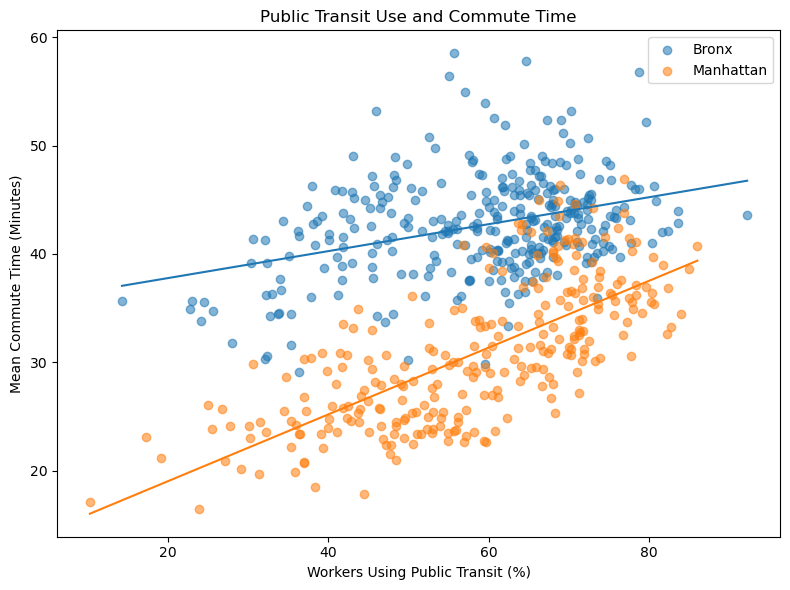

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

for borough in ["Bronx", "Manhattan"]:
    group = clean[clean["Borough"] == borough]

    # Scatter points
    plt.scatter(
        group["Transit"],
        group["MeanCommute"],
        alpha=0.55,
        label=borough
    )

    # Simple trend line
    slope, intercept = np.polyfit(
        group["Transit"],
        group["MeanCommute"],
        1
    )

    x_line = np.linspace(
        group["Transit"].min(),
        group["Transit"].max(),
        100
    )

    y_line = slope * x_line + intercept

    plt.plot(x_line, y_line)

plt.xlabel("Workers Using Public Transit (%)")
plt.ylabel("Mean Commute Time (Minutes)")
plt.title("Public Transit Use and Commute Time")
plt.legend()
plt.tight_layout()

plt.savefig(
    "transit_vs_commute.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

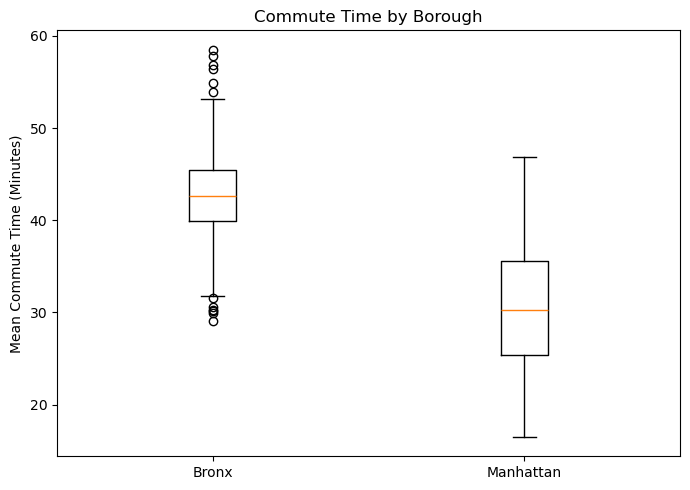

In [23]:
plt.figure(figsize=(7, 5))

bronx_commute = clean.loc[
    clean["Borough"] == "Bronx",
    "MeanCommute"
]

manhattan_commute = clean.loc[
    clean["Borough"] == "Manhattan",
    "MeanCommute"
]

plt.boxplot(
    [bronx_commute, manhattan_commute],
    tick_labels=["Bronx", "Manhattan"]
)

plt.ylabel("Mean Commute Time (Minutes)")
plt.title("Commute Time by Borough")
plt.tight_layout()

plt.savefig(
    "commute_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
